# 01. Data Foundation

Construye la capa base del proyecto:
- ingesta del historico internacional
- estandarizacion de columnas
- validacion de calidad
- creacion de targets basicos
- exportacion del dataset limpio para modelado

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

rawPath = Path("../data/raw/international_results.csv")
cleanPath = Path("../data/clean/clean_matches.csv")
rawUrl = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

print("Raw path:", rawPath)
print("Clean path:", cleanPath)

Raw path: ..\data\raw\international_results.csv
Clean path: ..\data\clean\clean_matches.csv


## 1. Carga del historico

In [2]:
if rawPath.exists():
    rawDf = pd.read_csv(rawPath)
    sourceUsed = str(rawPath)
else:
    rawDf = pd.read_csv(rawUrl)
    rawPath.parent.mkdir(parents=True, exist_ok=True)
    rawDf.to_csv(rawPath, index=False)
    sourceUsed = rawUrl

rawDf = rawDf.rename(
    columns={
        "home_team": "homeTeam",
        "away_team": "awayTeam",
        "home_score": "homeScore",
        "away_score": "awayScore",
    }
)
rawDf["date"] = pd.to_datetime(rawDf["date"])
rawDf = rawDf.sort_values("date", kind="mergesort").reset_index(drop=True)

print("Source used:", sourceUsed)
print("Shape rawDf:", rawDf.shape)
rawDf.head()

Source used: https://raw.githubusercontent.com/martj42/international_results/master/results.csv
Shape rawDf: (49071, 9)


,date,homeTeam,awayTeam,homeScore,awayScore,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


## 2. Validacion de calidad

In [3]:
requiredColumns = [
    "date",
    "homeTeam",
    "awayTeam",
    "homeScore",
    "awayScore",
    "tournament",
    "city",
    "country",
    "neutral",
]

missingColumns = [col for col in requiredColumns if col not in rawDf.columns]
assert not missingColumns, f"Faltan columnas requeridas: {missingColumns}"
assert rawDf[requiredColumns].isnull().sum().sum() == 0, "Hay nulos en columnas criticas"
assert (rawDf[["homeScore", "awayScore"]] < 0).sum().sum() == 0, "Hay marcadores negativos"

duplicateRows = rawDf.duplicated().sum()
duplicateMatchKeys = rawDf.duplicated(subset=["date", "homeTeam", "awayTeam"]).sum()

print("Duplicados exactos:", duplicateRows)
print("Duplicados por llave date-home-away:", duplicateMatchKeys)
print("Rango de fechas:", rawDf["date"].min(), "->", rawDf["date"].max())
print("Numero de torneos unicos:", rawDf["tournament"].nunique())

Duplicados exactos: 0
Duplicados por llave date-home-away: 1
Rango de fechas: 1872-11-30 00:00:00 -> 2026-01-26 00:00:00
Numero de torneos unicos: 191


## 3. Targets basicos

In [4]:
rawDf["matchResult"] = np.select(
    [
        rawDf["homeScore"] > rawDf["awayScore"],
        rawDf["homeScore"] < rawDf["awayScore"],
    ],
    [
        "win",
        "loss",
    ],
    default="draw",
)
rawDf["totalGoals"] = rawDf["homeScore"] + rawDf["awayScore"]

print(rawDf["matchResult"].value_counts(normalize=True).round(4))
rawDf.head()

matchResult
win     0.4900
loss    0.2827
draw    0.2273
Name: proportion, dtype: float64


,date,homeTeam,awayTeam,homeScore,awayScore,tournament,city,country,neutral,matchResult,totalGoals
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,win,6
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,win,3
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,4
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,win,3


## 4. Resumen exploratorio

In [5]:
summaryDf = pd.DataFrame(
    {
        "metric": [
            "matches",
            "teams",
            "tournaments",
            "avgHomeGoals",
            "avgAwayGoals",
            "avgTotalGoals",
        ],
        "value": [
            len(rawDf),
            pd.Index(rawDf["homeTeam"]).union(rawDf["awayTeam"]).nunique(),
            rawDf["tournament"].nunique(),
            rawDf["homeScore"].mean(),
            rawDf["awayScore"].mean(),
            rawDf["totalGoals"].mean(),
        ],
    }
)

summaryDf

,metric,value
0,matches,49071.000000
1,teams,333.000000
2,tournaments,191.000000
3,avgHomeGoals,1.756272
4,avgAwayGoals,1.182185
5,avgTotalGoals,2.938457


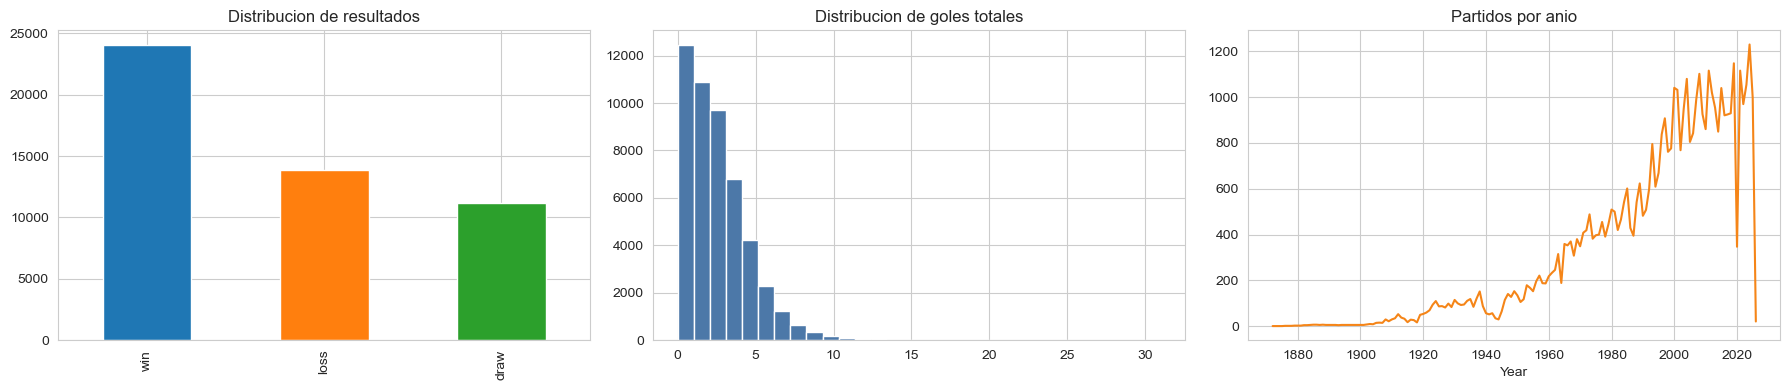

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

rawDf["matchResult"].value_counts().plot(kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title("Distribucion de resultados")
axes[0].set_xlabel("")

rawDf["totalGoals"].hist(bins=30, ax=axes[1], color="#4c78a8")
axes[1].set_title("Distribucion de goles totales")

rawDf.groupby(rawDf["date"].dt.year).size().plot(ax=axes[2], color="#f58518")
axes[2].set_title("Partidos por anio")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.show()

## 5. Filtro temporal y exportacion

In [7]:
analysisStartDate = pd.Timestamp("2000-01-01")

cleanDf = rawDf.loc[rawDf["date"] >= analysisStartDate].copy()
cleanDf = cleanDf.sort_values("date", kind="mergesort").reset_index(drop=True)

assert cleanDf.duplicated(subset=["date", "homeTeam", "awayTeam"]).sum() == 0, "Hay duplicados en el dataset limpio"
assert cleanDf[requiredColumns + ["matchResult", "totalGoals"]].isnull().sum().sum() == 0, "Hay nulos luego de la limpieza"

cleanPath.parent.mkdir(parents=True, exist_ok=True)
cleanDf.to_csv(cleanPath, index=False)

print("Shape cleanDf:", cleanDf.shape)
print("Rango limpio:", cleanDf["date"].min(), "->", cleanDf["date"].max())
print("Archivo exportado en:", cleanPath)
cleanDf.head()

Shape cleanDf: (25013, 11)
Rango limpio: 2000-01-04 00:00:00 -> 2026-01-26 00:00:00
Archivo exportado en: ..\data\clean\clean_matches.csv


,date,homeTeam,awayTeam,homeScore,awayScore,tournament,city,country,neutral,matchResult,totalGoals
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,win,3
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,win,7
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,draw,0
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,draw,2
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,draw,2
